In [19]:
from matplotlib import pyplot as plt
from pyppca import ppca
from sklearn import mixture
from sklearn.cluster import SpectralClustering
from operator import itemgetter
import os
from sklearn.decomposition import PCA
import numpy as np
import pickle
import sys
import pandas as pd
import scanpy as sc
from sklearn.metrics import *
data_folder_path = '../../../data'
sys.path.append(data_folder_path)
import matplotlib.patches as mpatches
import anndata as ad
from sklearn.neighbors import NearestNeighbors
import tensorflow as tf
import gpflow
float_type = gpflow.default_float()
import gpflux
from gpflow.config import default_float
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras import layers
import muon as mu
from muon import atac as ac
from muon import prot as pt
sys.path.append('../../../momogp/')
sys.path.append('../../../analysis/')
import mwgp as mwgp
from mwgp import GPD
import glob
import seaborn as sns
from evaluation import *
from GRM import *

def get_free_gpu_idx():
    """Get the index of the GPU with current lowest memory usage."""
    os.system("nvidia-smi -q -d Memory |grep -A4 GPU|grep Used >tmp")
    memory_available = [int(x.split()[2]) for x in open("tmp", "r").readlines()]
    return np.argmin(memory_available)

gpu_idx = get_free_gpu_idx()
print("Using GPU #%s" % gpu_idx)
os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_idx)

Using GPU #2


## Loading Dataset PBMC

In [20]:
file_path = os.path.join(data_folder_path, 'CITEseq', 'pbmc5k_citeseq.h5mu')
mdata = mu.read(file_path)
mu.pp.intersect_obs(mdata)
rna = mdata.mod['rna']
rna = rna[:,rna.var.highly_variable]
prot = mdata.mod['prot']

col_dict1 = {'CD14 mono': '#8000ff',
                 'memory-like NK': '#5641fd',
                 'CD8+ naïve T': '#2c7ef7',
                 'pDC': '#00b5eb',
                 'CD16 mono': '#2adddd',
                 'intermediate mono': '#54f6cb',
                 'CD4+ naïve T': '#80ffb4',
                 'mature B': '#abf69b',
                 'CD4+ memory T': '#d4dd80',
                 'NK': '#ffb360',
                 'CD8+ memory T': '#ff7e41',
                 'pre-B': '#ff4121',
                 'Treg': '#ff0000',
                 None: '#CDC9C9'}

In [21]:
rna

View of AnnData object with n_obs × n_vars = 3891 × 1734
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [22]:
prot

AnnData object with n_obs × n_vars = 3891 × 32
    obs: 'celltype'
    var: 'gene_ids', 'feature_types', 'highly_variable'
    uns: 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [23]:
RNA_Normalized_2000 = (rna.X-np.mean(rna.X,0))/np.std(rna.X,0)

prot_Normalized_2000 = (prot.X-np.mean(prot.X,0))/np.std(prot.X,0)

## Gene Relevance Map
#### We will load the cell and gene embedding of the best result, associated with the 2D embedded MOGP with 500 epochs. Then, we load their meta-cells and meta-genes.
#### Its gene relevance map and meta gene relevance map are provided in subsequent steps. 

In [24]:
dim_arr=[2]
num_epochs_arr=[500]
n_inducing_points_arr=[512]
batch_size_arr=[100000]
with_PCA_arr=[0]
with_PPCA_arr=[0]
scale_emb1_arr=[0]
scale_emb2_arr=[0]
emb_reg_arr=[0.001]
lr = float(0.01)
kernel = ["RBF"]


dim1 = dim_arr[0]
dim2 = dim_arr[0]
dim3 = dim_arr[0]
num_epochs = num_epochs_arr[0]
n_inducing_points1 = n_inducing_points_arr[0]
n_inducing_points2 = n_inducing_points_arr[0]
batch_size = batch_size_arr[0]
with_PCA=with_PCA_arr[0]
with_PPCA=with_PPCA_arr[0]
scale_emb1=scale_emb1_arr[0]
scale_emb2=scale_emb2_arr[0]
emb_reg=emb_reg_arr[0]

In [25]:
title = 'dim1='+str(dim1)+'  dim2='+str(dim2)+'  dim3='+str(dim3)+'  InducingPoints1='+str(n_inducing_points1)+'  InducingPoints2='+str(n_inducing_points2)+'  BatchSize='+str(batch_size)+'  epochs='+str(num_epochs)+'  emb_reg='+str(emb_reg)+' with_PCA='+str(with_PCA)
save_path = './PBMC5KCITEseqRNA-GPFlux  '+title+'/embs1.csv' 
file = open(save_path,'rb')
object_file = pickle.load(file)
file.close()

RNA_struct_MOGP = ad.AnnData(object_file)
RNA_struct_MOGP.obsm['X_umap']= object_file

In [26]:
title = 'dim1='+str(dim1)+'  dim2='+str(dim2)+'  dim3='+str(dim3)+'  InducingPoints1='+str(n_inducing_points1)+'  InducingPoints2='+str(n_inducing_points2)+'  BatchSize='+str(batch_size)+'  epochs='+str(num_epochs)+'  emb_reg='+str(emb_reg)+' with_PCA='+str(with_PCA)
save_path = './PBMC5KCITEseqRNA-GPFlux  '+title+'/embs2.csv' 
file = open(save_path,'rb')
object_file = pickle.load(file)
file.close()

Genes_struct_MOGP = ad.AnnData(object_file)
Genes_struct_MOGP.obsm['X_umap']= object_file

In [27]:
n_SEACells_cells=60
title = 'dim1='+str(dim1)+'  dim2='+str(dim2)+'  dim3='+str(dim3)+'  InducingPoints1='+str(n_inducing_points1)+'  InducingPoints2='+str(n_inducing_points2)+'  BatchSize='+str(batch_size)+'  epochs='+str(num_epochs)+'  emb_reg='+str(emb_reg)+' with_PCA='+str(with_PCA)
save_path = './PBMC5KCITEseqRNA-GPFlux  '+title+'/'+'NumMetaCells='+str(n_SEACells_cells)+'seaCell_metaCells.csv' 
file = open(save_path,'rb')
metaCells = pickle.load(file)
file.close()
RNA_struct_MOGP.obs[['SEACell']]=metaCells

n_SEACells_genes=120
title = 'dim1='+str(dim1)+'  dim2='+str(dim2)+'  dim3='+str(dim3)+'  InducingPoints1='+str(n_inducing_points1)+'  InducingPoints2='+str(n_inducing_points2)+'  BatchSize='+str(batch_size)+'  epochs='+str(num_epochs)+'  emb_reg='+str(emb_reg)+' with_PCA='+str(with_PCA)
save_path = './PBMC5KCITEseqRNA-GPFlux  '+title+'/'+'NumMetaCells='+str(n_SEACells_genes)+'seaCell_metaGenes.csv' 
file = open(save_path,'rb')
metaGenes = pickle.load(file)
file.close()
Genes_struct_MOGP.obs[['SEACell']]=metaGenes

/home/zmoslehi/miniconda3/envs/MOGP-TF-Florian/lib/python3.9/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/home/zmoslehi/miniconda3/envs/MOGP-TF-Florian/lib/python3.9/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


<AxesSubplot: xlabel='0', ylabel='1'>

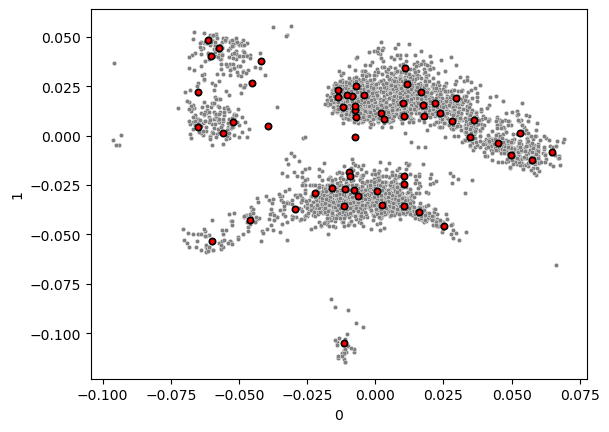

In [28]:
umap = pd.DataFrame(RNA_struct_MOGP.obsm['X_umap']).set_index(RNA_struct_MOGP.obs_names).join(RNA_struct_MOGP.obs['SEACell'])
umap['SEACell'] = umap['SEACell'].astype("category")
mcs_cells = umap.groupby('SEACell').mean().reset_index()
sns.scatterplot(x=0, y=1,
                        color='grey',
                        data=umap,
                        s=10,
                        cmap='Set2',
                        legend=None)
sns.scatterplot(x=0, y=1, s=20,
                color='red',
                data=mcs_cells,
                cmap='Set2',
                edgecolor='black', linewidth=1.25,
                legend=None)

/home/zmoslehi/miniconda3/envs/MOGP-TF-Florian/lib/python3.9/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/home/zmoslehi/miniconda3/envs/MOGP-TF-Florian/lib/python3.9/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


<AxesSubplot: xlabel='0', ylabel='1'>

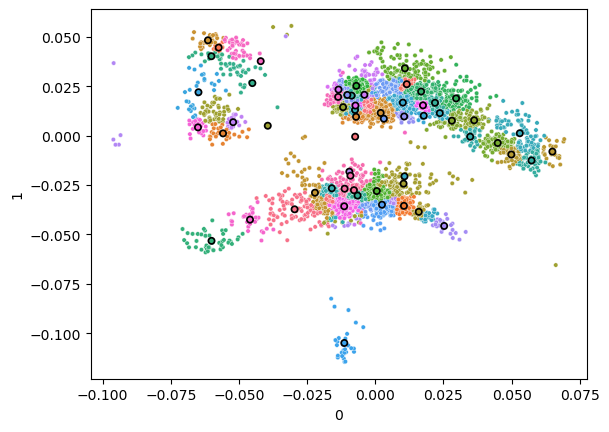

In [29]:
sns.scatterplot(x=0, y=1,
                        hue='SEACell',
                        data=umap,
                        s=10,
                        cmap='Set2',
                        legend=None)
sns.scatterplot(x=0, y=1, s=20,
                hue='SEACell',
                data=mcs_cells,
                cmap='Set2',
                edgecolor='black', linewidth=1.25,
                legend=None)

/home/zmoslehi/miniconda3/envs/MOGP-TF-Florian/lib/python3.9/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/home/zmoslehi/miniconda3/envs/MOGP-TF-Florian/lib/python3.9/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


<AxesSubplot: xlabel='0', ylabel='1'>

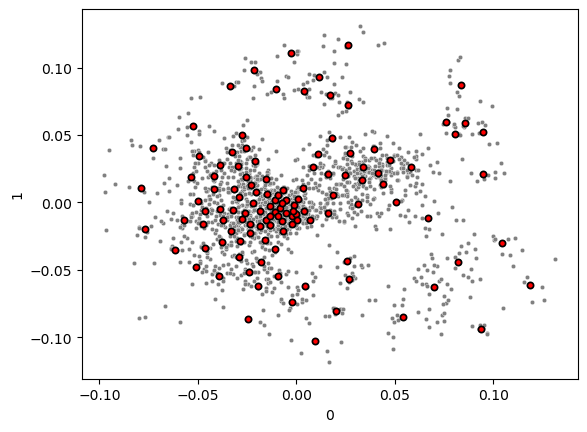

In [30]:
umap = pd.DataFrame(Genes_struct_MOGP.obsm['X_umap']).set_index(Genes_struct_MOGP.obs_names).join(Genes_struct_MOGP.obs['SEACell'])
umap['SEACell'] = umap['SEACell'].astype("category")
mcs_genes = umap.groupby('SEACell').mean().reset_index()
sns.scatterplot(x=0, y=1,
                        color='grey',
                        data=umap,
                        s=10,
                        cmap='Set2',
                        legend=None)
sns.scatterplot(x=0, y=1, s=20,
                color='red',
                data=mcs_genes,
                cmap='Set2',
                edgecolor='black', linewidth=1.25,
                legend=None)

/home/zmoslehi/miniconda3/envs/MOGP-TF-Florian/lib/python3.9/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/home/zmoslehi/miniconda3/envs/MOGP-TF-Florian/lib/python3.9/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


<AxesSubplot: xlabel='0', ylabel='1'>

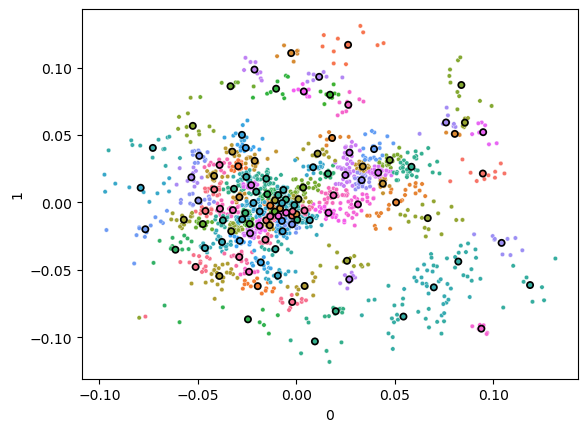

In [31]:
sns.scatterplot(x=0, y=1,
                        hue='SEACell',
                        data=umap,
                        s=10,
                        cmap='Set2',
                        legend=None)
sns.scatterplot(x=0, y=1, s=20,
                hue='SEACell',
                data=mcs_genes,
                cmap='Set2',
                edgecolor='black', linewidth=1.25,
                legend=None)

In [32]:
RNA_struct_MOGP

AnnData object with n_obs × n_vars = 3891 × 2
    obs: 'SEACell'
    obsm: 'X_umap'

In [33]:
Genes_struct_MOGP

AnnData object with n_obs × n_vars = 1734 × 2
    obs: 'SEACell'
    obsm: 'X_umap'

#### The functions related to Gene Relevance MAP are defined based on the following paper: 
"Angerer, P., Fischer, D.S., Theis, F.J., Scialdone, A. and Marr, C., 2020. Automatic identification of relevant genes from low-dimensional embeddings of single-cell RNA-seq data. Bioinformatics, 36(15), pp.4291-4295."

In [34]:
n_neighbors=6
#The value of the rg_max parameter significantly impacts the results and requires careful tuning to achieve optimal performance.
rg_max=100
n_bins=100

In [18]:
rank_dhatgc = rank_dhatgc_score(RNA_struct_MOGP, Genes_struct_MOGP, RNA_Normalized_2000, n_neighbors)

In [18]:
title = 'dim1='+str(dim1)+'  dim2='+str(dim2)+'  dim3='+str(dim3)+'  InducingPoints1='+str(n_inducing_points1)+'  InducingPoints2='+str(n_inducing_points2)+'  BatchSize='+str(batch_size)+'  epochs='+str(num_epochs)+'  emb_reg='+str(emb_reg)+' with_PCA='+str(with_PCA)
save_path = './PBMC5KCITEseqRNA-GPFlux  '+title+'/rank_dhatgc_GeneRelevance3.csv' 
file = open(save_path,'wb')
pickle.dump(rank_dhatgc,file)
file.close()

In [35]:
title = 'dim1='+str(dim1)+'  dim2='+str(dim2)+'  dim3='+str(dim3)+'  InducingPoints1='+str(n_inducing_points1)+'  InducingPoints2='+str(n_inducing_points2)+'  BatchSize='+str(batch_size)+'  epochs='+str(num_epochs)+'  emb_reg='+str(emb_reg)+' with_PCA='+str(with_PCA)
save_path = './PBMC5KCITEseqRNA-GPFlux  '+title+'/rank_dhatgc_GeneRelevance3.csv' 
file = open(save_path,'rb')
rank_dhatgc = pickle.load(file)
file.close()

#### Gene Relevance for some famous genes: this is done for testing the results

In [36]:
LR_gPsi, avg_Psi = LRgPsi_avgPsi_score(RNA_struct_MOGP, Genes_struct_MOGP, rank_dhatgc, rg_max)

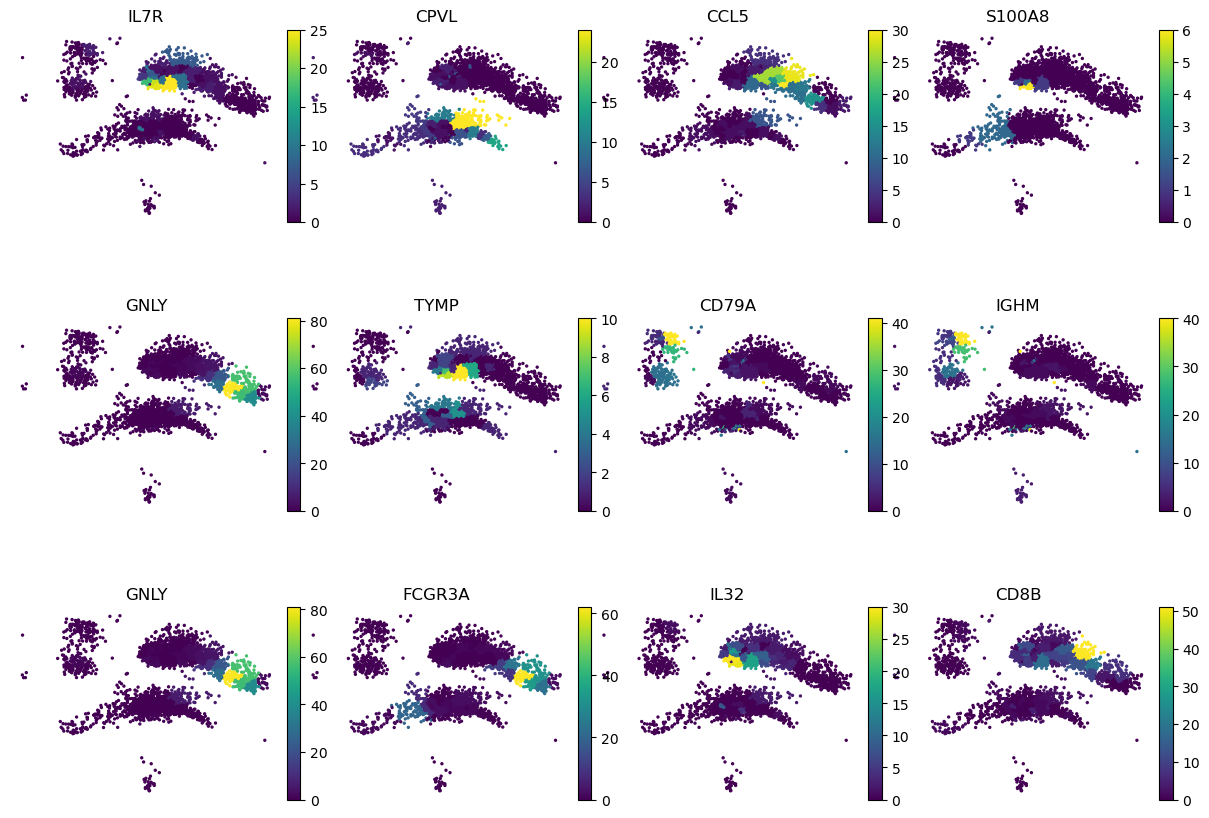

In [37]:
gene_list=["IL7R", "CPVL", "CCL5", "S100A8", "GNLY", "TYMP", "CD79A", "IGHM", "GNLY", "FCGR3A","IL32","CD8B"]
Gene_Relevance_Map(rna, gene_list, LR_gPsi, avg_Psi)

#### Global Meta Gene Relevance: Instead of computing gene relevance, we compute the relevance of meta-genes to the cell embedding space. We then sort these meta-genes to compute the Global Meta Gene Relevance Map. For further information, please refer to the paper mentioned above.

In [38]:
rank_dhatMetagc = rank_dhatMetagc_score(RNA_struct_MOGP, Genes_struct_MOGP, rank_dhatgc)

In [39]:
LR_gPsi, avg_Psi, Global_idx = LRgPsi_avgPsi_GlobalMetascore(RNA_struct_MOGP, Genes_struct_MOGP, rank_dhatMetagc, rg_max)

In [40]:
mcs_genes_sorted0=mcs_genes[0].values[Global_idx]
mcs_genes_sorted1=mcs_genes[1].values[Global_idx]
mcs_genes_sorted_SEACell=mcs_genes['SEACell'].values[Global_idx]

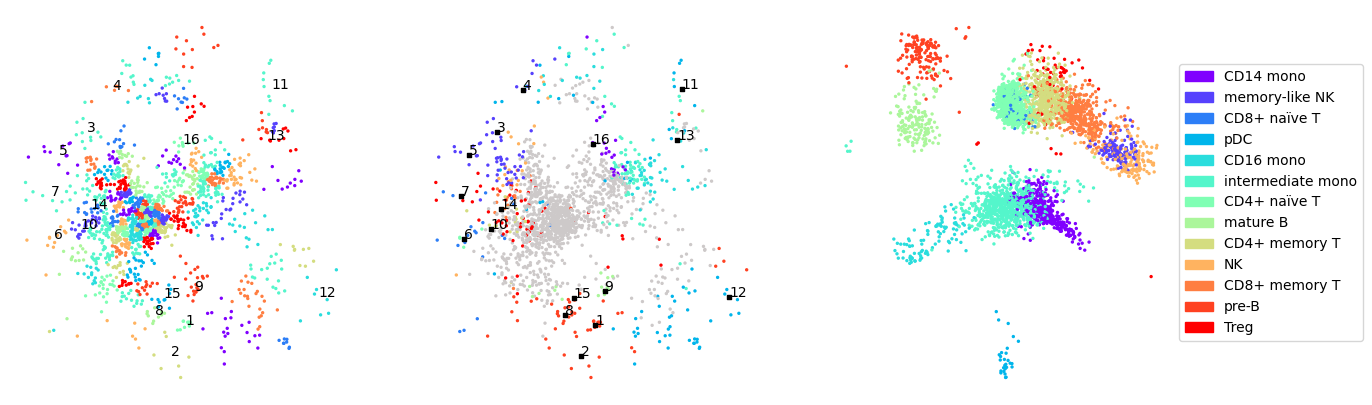

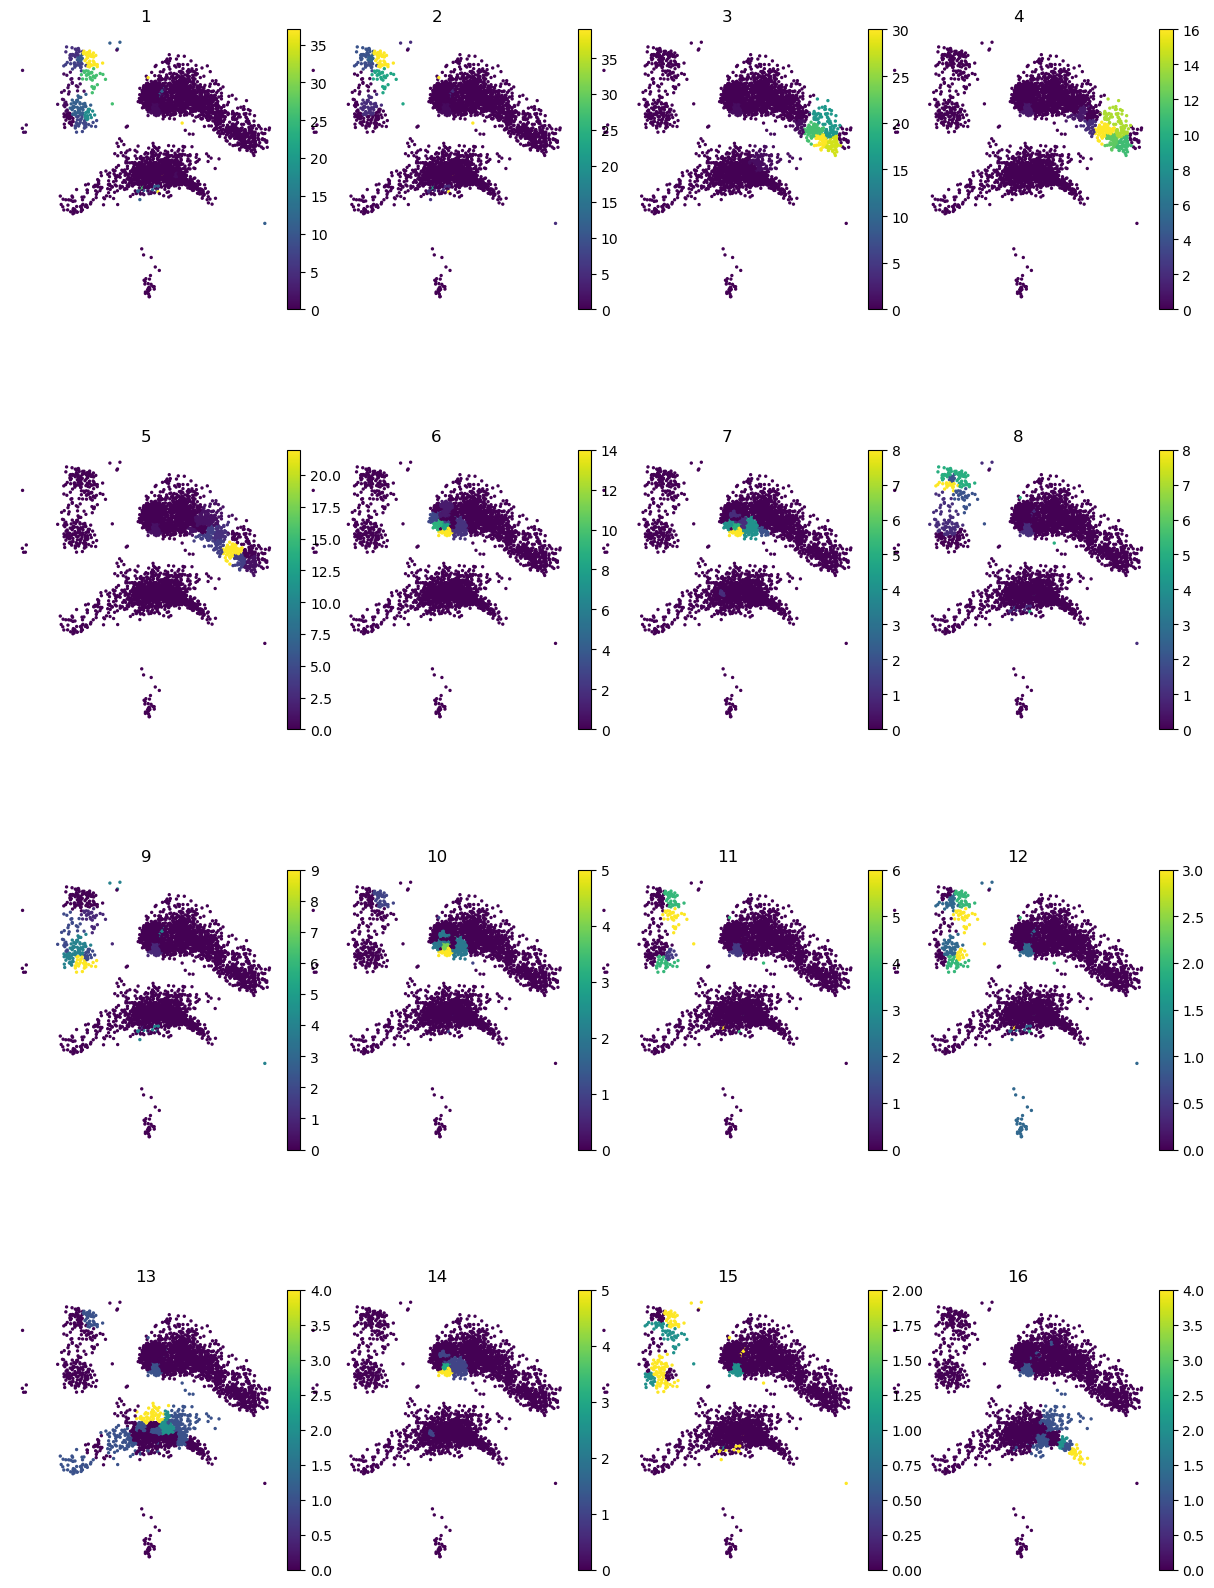

In [41]:
Global_Gene_Relevance_Map_CITE(rna, RNA_struct_MOGP, Genes_struct_MOGP, col_dict1, mcs_genes_sorted0, mcs_genes_sorted1, mcs_genes_sorted_SEACell, LR_gPsi, avg_Psi, offset=0, topRG=16)

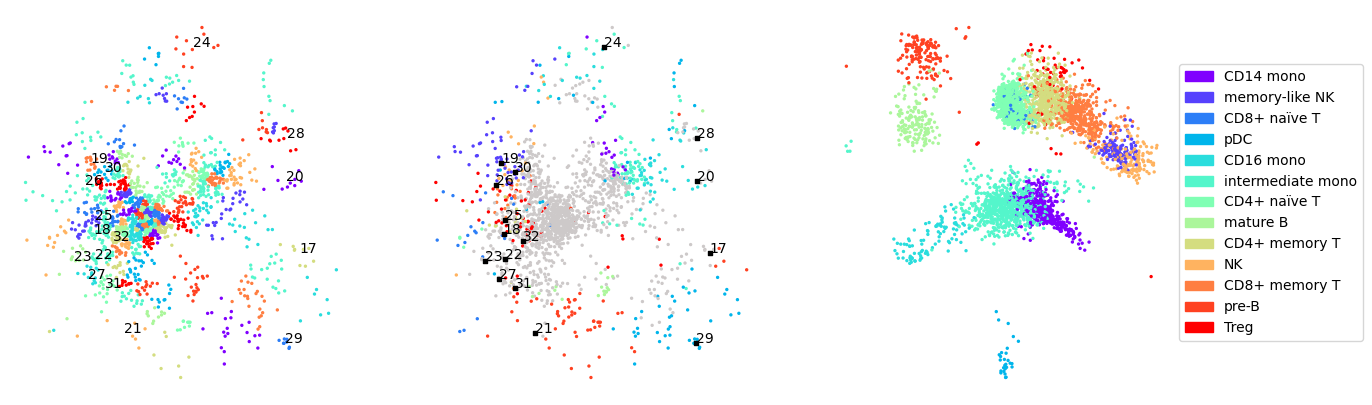

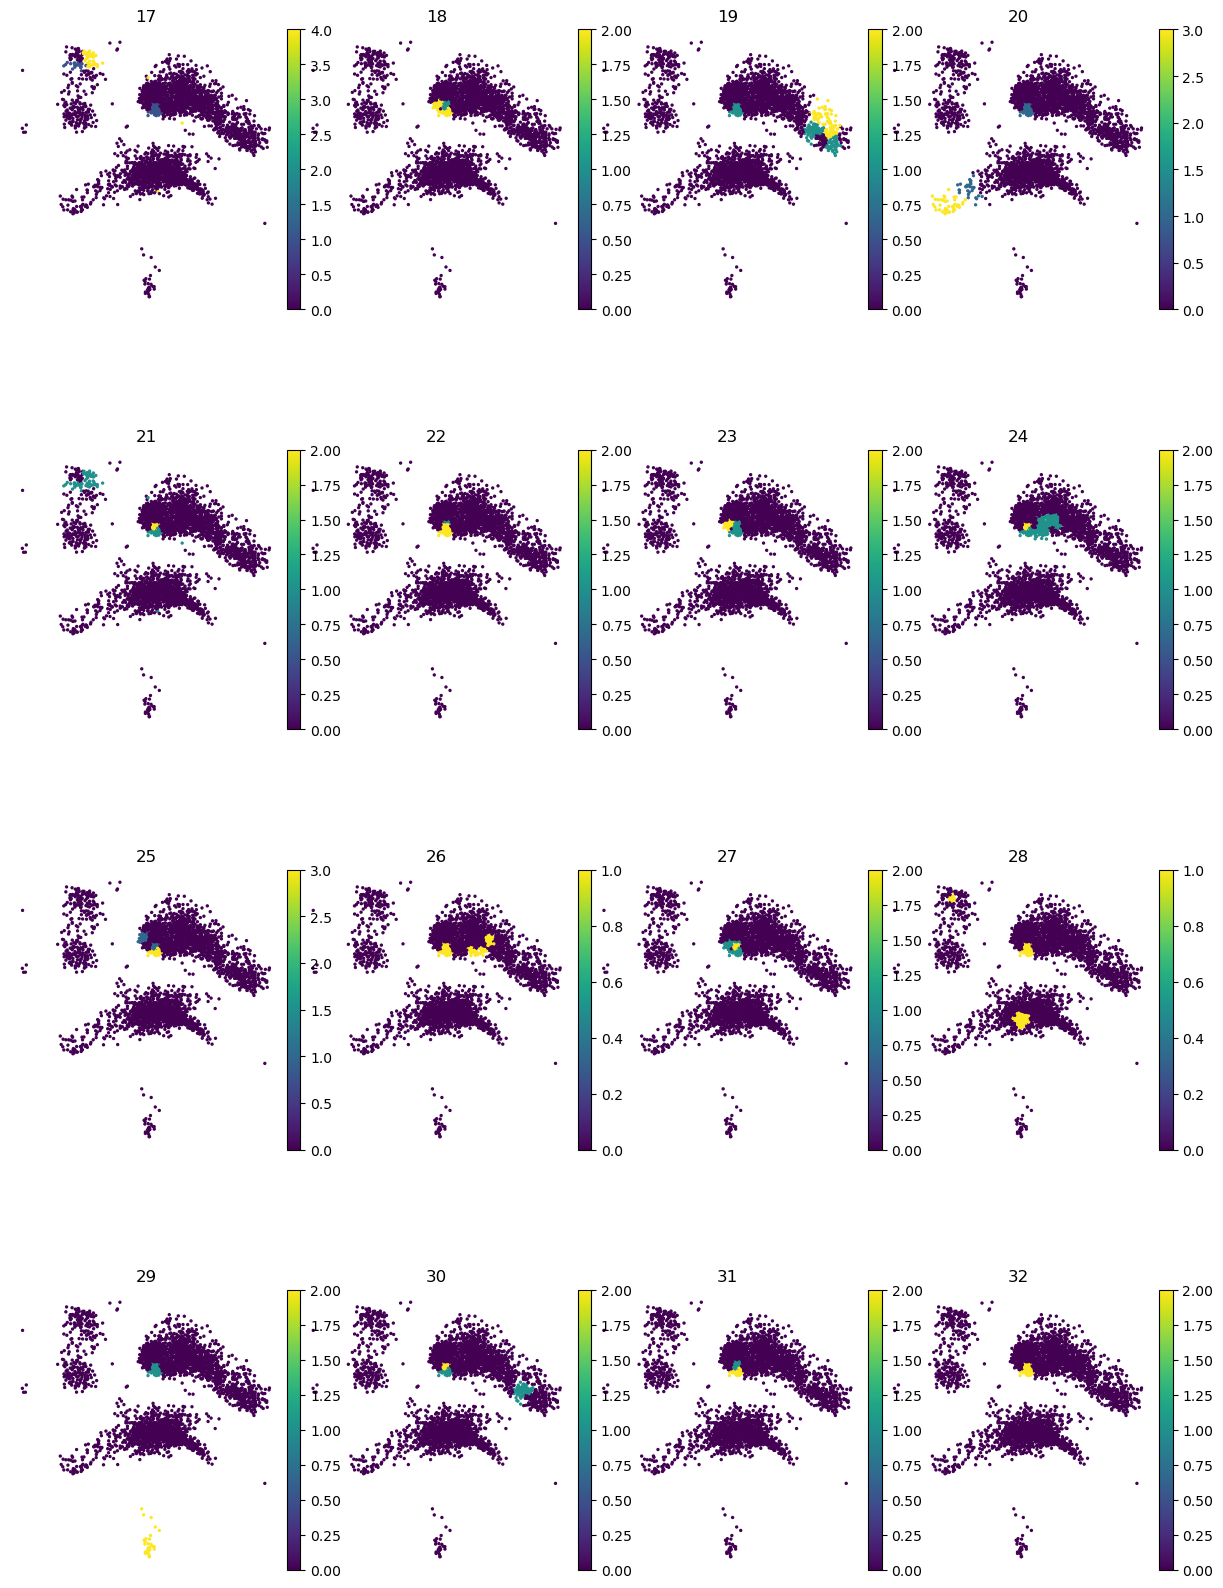

In [42]:
Global_Gene_Relevance_Map_CITE(rna, RNA_struct_MOGP, Genes_struct_MOGP, col_dict1, mcs_genes_sorted0, mcs_genes_sorted1, mcs_genes_sorted_SEACell, LR_gPsi, avg_Psi, offset=16, topRG=16)

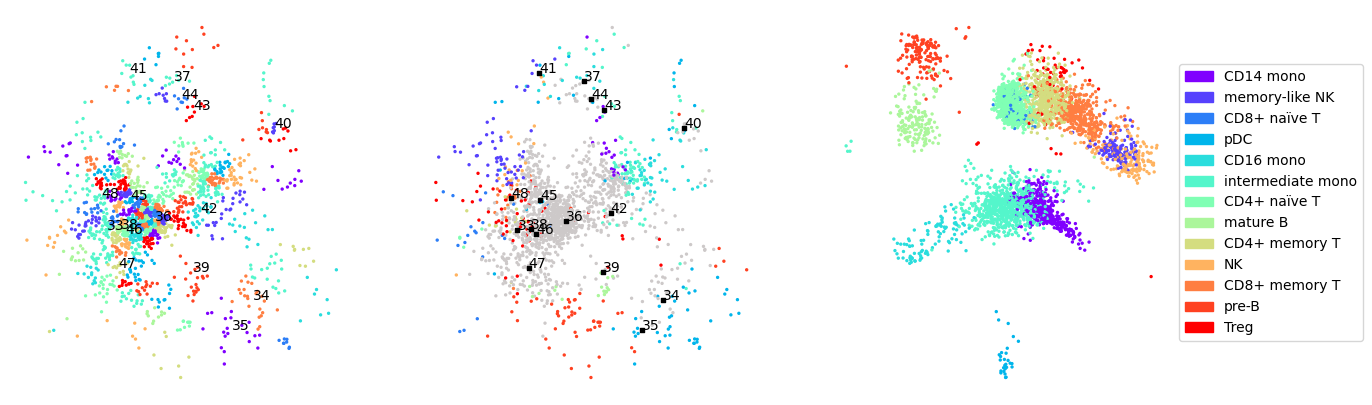

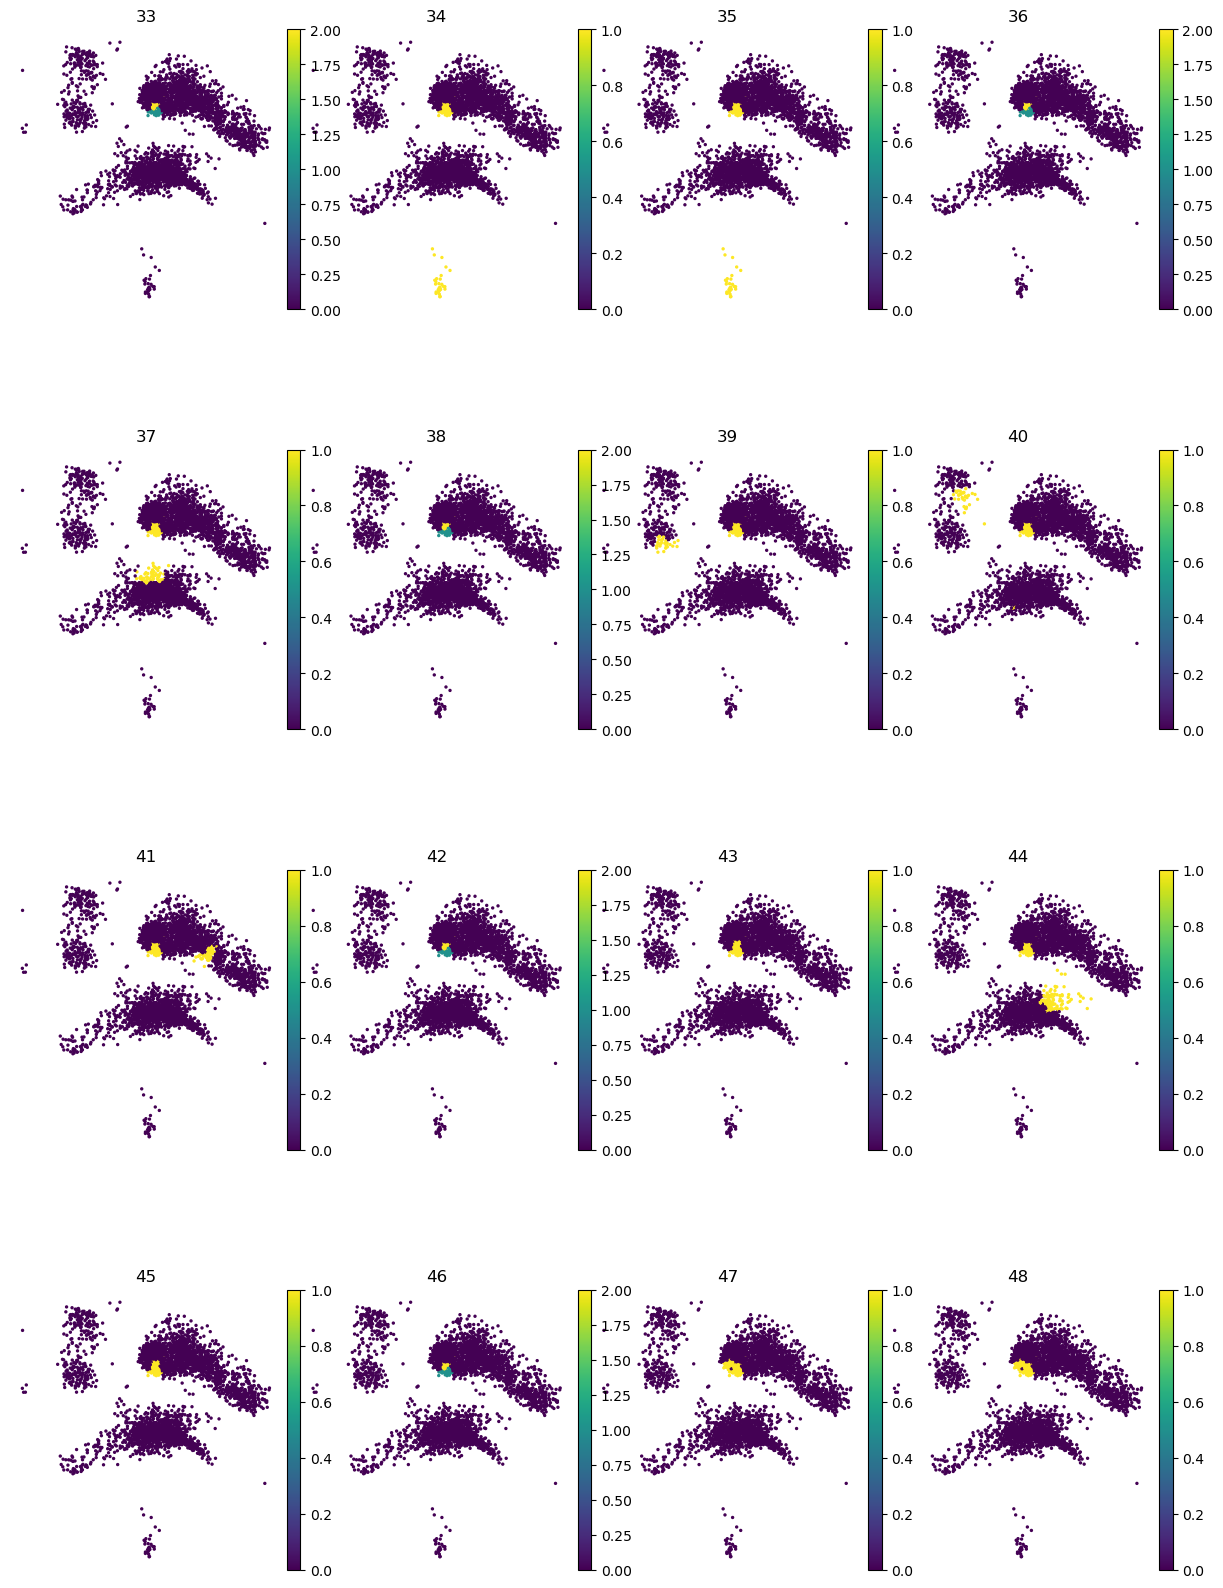

In [43]:
Global_Gene_Relevance_Map_CITE(rna, RNA_struct_MOGP, Genes_struct_MOGP, col_dict1, mcs_genes_sorted0, mcs_genes_sorted1, mcs_genes_sorted_SEACell, LR_gPsi, avg_Psi, offset=32, topRG=16)

#### Merged_Meta_Genes: We will merge some of the meta-genes that are very close together in the gene embedding and have similar meta-gene relevance maps. We aim to retain those meta-genes that cover all cells in the cell embedding.

In [44]:
rank_dhatMetagc = rank_dhatMetagc_score(RNA_struct_MOGP, Genes_struct_MOGP, rank_dhatgc)

In [45]:
[cells,embs1_num]=RNA_struct_MOGP.obsm['X_umap'].shape
metaGenes=rank_dhatMetagc.shape[1]
GR_g=np.zeros(metaGenes)
for g in range(metaGenes):
    nom=np.sum([rank_dhatMetagc[:,g]<=np.repeat(rg_max, cells)])
    s = nom/cells
    GR_g[g]=s  
idx = GR_g.argsort()[-metaGenes:][::-1]
rank_dhatMetagc=rank_dhatMetagc[:,idx]

In [46]:
mcs_genes_sorted0=mcs_genes[0].values[idx]
mcs_genes_sorted1=mcs_genes[1].values[idx]
mcs_genes_sorted_SEACell=mcs_genes['SEACell'].values[idx]


In [47]:
metaGenesList_new=[[0,1,7,20],[14],[8],[5,6,9,13,32,17,21,22,24,31,26,30,31,21,22,26],[25],[2,3,4,18],[19],[12],[15],[28, 33],[35],[37]]

In [48]:
mcs_genes_sorted0_new=[]
mcs_genes_sorted1_new=[]
mcs_genes_sorted_SEACell_new=[]
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[0]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[1]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[2]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[3]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[4]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[5]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[6]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[7]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[8]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[9]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[10]]))
mcs_genes_sorted0_new.append(np.mean(mcs_genes_sorted0[metaGenesList_new[11]]))

mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[0]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[1]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[2]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[3]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[4]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[5]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[6]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[7]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[8]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[9]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[10]]))
mcs_genes_sorted1_new.append(np.mean(mcs_genes_sorted1[metaGenesList_new[11]]))

mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[0]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[1]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[2]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[3]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[4]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[5]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[6]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[7]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[8]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[9]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[10]])
mcs_genes_sorted_SEACell_new.append(mcs_genes_sorted_SEACell[metaGenesList_new[11]])

In [49]:
LR_gPsi, avg_Psi = LRgPsi_avgPsi_MergedMetascore(RNA_struct_MOGP, Genes_struct_MOGP, metaGenesList_new, rank_dhatMetagc, rg_max)

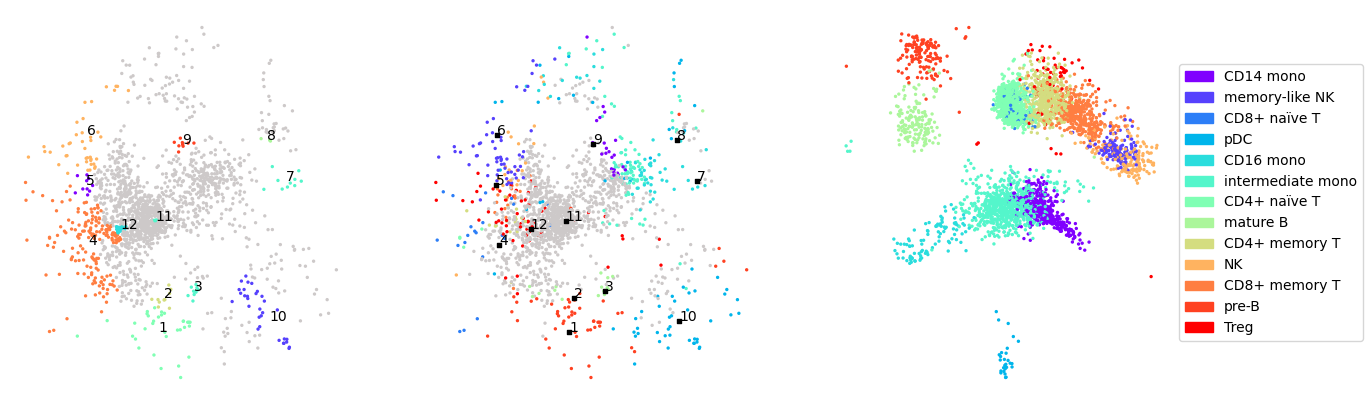

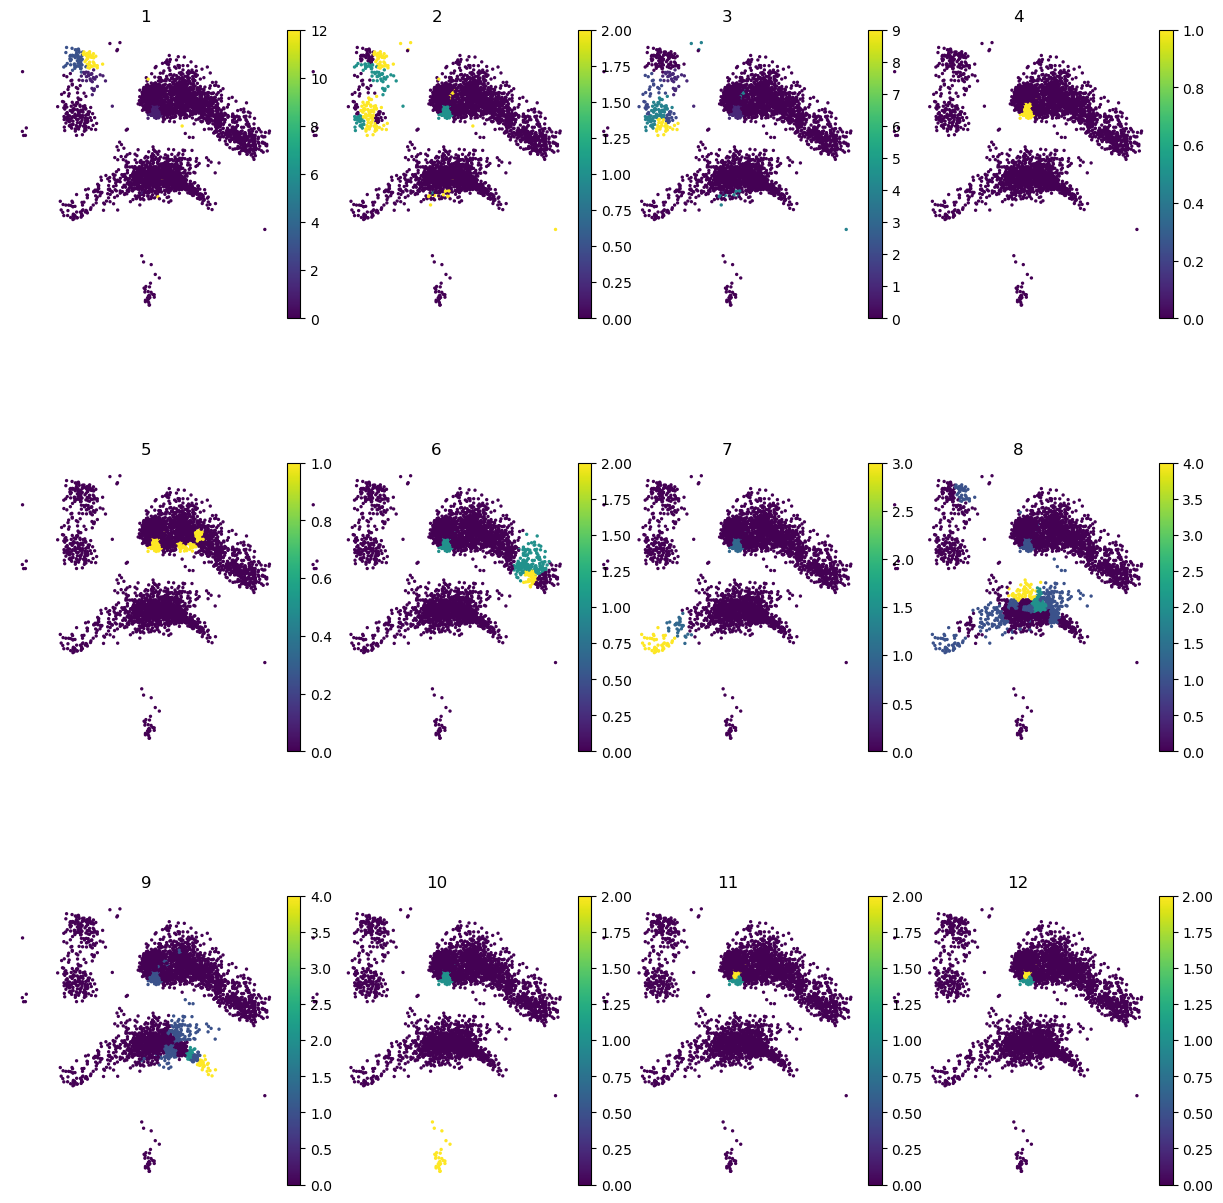

In [50]:
Global_Gene_Relevance_Map_CITE(rna, RNA_struct_MOGP, Genes_struct_MOGP, col_dict1, mcs_genes_sorted0_new, mcs_genes_sorted1_new, mcs_genes_sorted_SEACell_new, LR_gPsi, avg_Psi, offset=0, topRG=12)

#### GEA: Over-representation analysis

In [35]:
gene_sets_all = os.path.join(data_folder_path,  "h.all.v2023.1.Hs.symbols.gmt")
gene_sets_CellType = os.path.join(data_folder_path,  "c8.all.v2023.1.Hs.symbols.gmt")
GEA(rna, RNA_struct_MOGP, Genes_struct_MOGP, mcs_genes_sorted_SEACell_new, gene_sets_all, gene_sets_CellType)

2024-06-04 12:06:24,448 [INFO] User defined gene sets is given: ../../../data/c8.all.v2023.1.Hs.symbols.gmt
2024-06-04 12:06:24,471 [INFO] Input dict object named with gs_ind_2


Top relenance Gene: 1


2024-06-04 12:06:25,252 [WARNING] Input library not found: unknown. Skip
2024-06-04 12:06:25,254 [INFO] Run: c8.all.v2023.1.Hs.symbols.gmt 
2024-06-04 12:06:25,404 [INFO] Run: gs_ind_2 
2024-06-04 12:06:25,511 [INFO] Done.


Enrichment_CellType:


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
113,gs_ind_2,HAY_BONE_MARROW_FOLLICULAR_B_CELL,17/69,1.450893e-16,6.470982e-15,25.416394,926.915115,TNFRSF13C;LINC00926;BANK1;MS4A1;ADAM28;HLA-DOB...
107,gs_ind_2,HAY_BONE_MARROW_CD34_POS_CLP,1/1,1.903114e-02,1.632286e-01,53.338462,211.309841,CD200


...

Enrichment_CellType:
Top relenance Gene: 12


2024-06-04 12:06:36,387 [WARNING] Input library not found: unknown. Skip
2024-06-04 12:06:36,389 [INFO] Run: c8.all.v2023.1.Hs.symbols.gmt 
2024-06-04 12:06:36,470 [INFO] Run: gs_ind_2 
2024-06-04 12:06:36,530 [INFO] Done.


Enrichment_CellType:


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
38,gs_ind_2,HAY_BONE_MARROW_PLASMA_CELL,1/22,0.206242,0.619792,6.523810,10.299177,CCR10
39,gs_ind_2,HAY_BONE_MARROW_PRO_B,1/30,0.270728,0.619792,4.790164,6.259027,RTKN2


,Meta Gene,Term,Adjusted P-value,Combined Score
113,1,HAY_BONE_MARROW_FOLLICULAR_B_CELL,0.0,926.915115
107,1,HAY_BONE_MARROW_CD34_POS_CLP,0.163229,211.309841
60,2,HAY_BONE_MARROW_FOLLICULAR_B_CELL,0.0,1829.581417
59,2,HAY_BONE_MARROW_CD34_POS_PRE_PC,0.295534,58.729453
49,3,HAY_BONE_MARROW_PLASMA_CELL,0.006769,302.329586
48,3,HAY_BONE_MARROW_FOLLICULAR_B_CELL,0.010172,129.686813
283,4,HAY_BONE_MARROW_NAIVE_T_CELL,0.0,3120.829169
286,4,HAY_BONE_MARROW_PRE_DENDRITIC,0.479916,22.971431
53,5,HAY_BONE_MARROW_NK_CELLS,0.000084,280.389892
51,5,HAY_BONE_MARROW_CD8_T_CELL,0.064592,42.737024
